# Loan Approval Prediction Case Study

## Project Overview

This project aims to build a machine learning model that predicts whether a loan application will be approved based on applicant information. The workflow includes data loading, exploratory data analysis (EDA), data preprocessing, handling class imbalance, model building, evaluation, and business interpretation of results.

### Objectives
- Understand the dataset through exploratory analysis.
- Clean and preprocess the data.
- Handle class imbalance using appropriate techniques.
- Train and compare multiple machine learning models.
- Evaluate model performance using relevant metrics.
- Provide business-oriented insights and recommendations.

Data Loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [ ]:
import kagglehub

path = kagglehub.dataset_download(
    "bhanupratapbiswas/loan-approval-prediction-case-study"
)

print(path)

100%|██████████| 9.72k/9.72k [00:00<00:00, 14.6MB/s]

Extracting files...
/root/.cache/kagglehub/datasets/bhanupratapbiswas/loan-approval-prediction-case-study/versions/1


In [ ]:
import os
print(os.listdir(path))

['loan_prediction.csv']


In [ ]:
df = pd.read_csv(
    "/root/.cache/kagglehub/datasets/bhanupratapbiswas/loan-approval-prediction-case-study/versions/1/loan_prediction.csv"
)

In [ ]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [ ]:
df.shape

(614, 13)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 67.2+ KB


Data Preprocessing

In [ ]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
Credit_History,50
Self_Employed,32
LoanAmount,22
Dependents,15
Loan_Amount_Term,14
Gender,13
Married,3
Education,0
Loan_ID,0
CoapplicantIncome,0


In [ ]:
df.isnull().mean() * 100

,0
Loan_ID,0.000000
Gender,2.117264
Married,0.488599
Dependents,2.442997
Education,0.000000
Self_Employed,5.211726
ApplicantIncome,0.000000
CoapplicantIncome,0.000000
LoanAmount,3.583062
Loan_Amount_Term,2.280130


In [ ]:
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
df['Married'].fillna(df['Married'].mode()[0], inplace=True)
df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0], inplace=True)

df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)
df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)

/tmp/ipykernel_1854/3352131350.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
/tmp/ipykernel_1854/3352131350.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tru

In [ ]:
df.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [ ]:
df = df.drop('Loan_ID', axis=1)

In [ ]:
df.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

Feature Encoding

In [ ]:
df.select_dtypes(include='object').columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'Property_Area', 'Loan_Status'],
      dtype='object')

In [ ]:
for col in df.select_dtypes(include='object').columns:
    print(col)
    print(df[col].unique())
    print("-" * 30)

Gender
['Male' 'Female']
------------------------------
Married
['No' 'Yes']
------------------------------
Dependents
['0' '1' '2' '3+']
------------------------------
Education
['Graduate' 'Not Graduate']
------------------------------
Self_Employed
['No' 'Yes']
------------------------------
Property_Area
['Urban' 'Rural' 'Semiurban']
------------------------------
Loan_Status
['Y' 'N']
------------------------------


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


Feature and Target Selection

In [ ]:
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (614, 11)
Target shape: (614,)


Class Distribution Analysis

In [ ]:
y.value_counts()

,count
Loan_Status,
1,422
0,192


In [ ]:
y.value_counts(normalize=True) * 100

,proportion
Loan_Status,
1,68.729642
0,31.270358


Train-Test Split and Feature Scaling

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (491, 11)
X_test : (123, 11)
y_train: (491,)
y_test : (123,)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

(491, 11)
(123, 11)


Logistic Regression Model

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(random_state=42)

lr.fit(X_train_scaled, y_train)

print("Training Accuracy:", lr.score(X_train_scaled, y_train))
print("Testing Accuracy :", lr.score(X_test_scaled, y_test))

Training Accuracy: 0.7983706720977597
Testing Accuracy : 0.8617886178861789


Logistic Regression Evaluation

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = lr.predict(X_test_scaled)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[22 16]
 [ 1 84]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.58      0.72        38
           1       0.84      0.99      0.91        85

    accuracy                           0.86       123
   macro avg       0.90      0.78      0.81       123
weighted avg       0.88      0.86      0.85       123



In [ ]:
from sklearn.metrics import roc_auc_score

y_prob = lr.predict_proba(X_test_scaled)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.8018575851393189


Random Forest Model

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

print("Training Accuracy:", rf.score(X_train, y_train))
print("Testing Accuracy :", rf.score(X_test, y_test))

Training Accuracy: 1.0
Testing Accuracy : 0.8292682926829268


Random Forest Evaluation

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

rf_pred = rf.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

rf_prob = rf.predict_proba(X_test)[:, 1]

print("ROC-AUC Score:", roc_auc_score(y_test, rf_prob))

Confusion Matrix:
[[24 14]
 [ 7 78]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.63      0.70        38
           1       0.85      0.92      0.88        85

    accuracy                           0.83       123
   macro avg       0.81      0.77      0.79       123
weighted avg       0.83      0.83      0.82       123

ROC-AUC Score: 0.795046439628483


Feature Importance Analysis

In [ ]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
9,Credit_History,0.242296
5,ApplicantIncome,0.209001
7,LoanAmount,0.192555
6,CoapplicantIncome,0.113800
2,Dependents,0.053360
10,Property_Area,0.048456
8,Loan_Amount_Term,0.048202
1,Married,0.027660
3,Education,0.027166
0,Gender,0.019237


Feature Importance Visualization

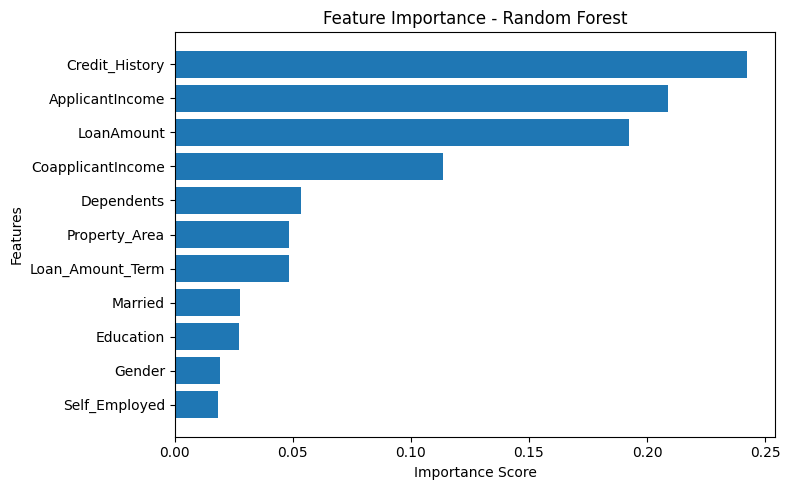

In [ ]:
plt.figure(figsize=(8,5))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.title('Feature Importance - Random Forest')

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

Model Comparison

In [ ]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [0.8618, 0.8293],
    'ROC_AUC': [0.8019, 0.7950]
})

comparison

,Model,Accuracy,ROC_AUC
0,Logistic Regression,0.8618,0.8019
1,Random Forest,0.8293,0.7950


Deployment Threshold Analysis

In [ ]:
y_prob = lr.predict_proba(X_test_scaled)[:, 1]

pd.Series(y_prob).describe()

,0
count,123.000000
mean,0.657476
std,0.277584
min,0.040128
25%,0.662157
50%,0.782301
75%,0.829162
max,0.878856


## Conclusion

In this project, a Loan Approval Prediction system was developed using machine learning techniques. The dataset was preprocessed by handling missing values, encoding categorical variables, and selecting relevant features.

Two classification models, Logistic Regression and Random Forest, were trained and evaluated. Logistic Regression achieved the best overall performance with a testing accuracy of 86.18% and a ROC-AUC score of 0.8019. Random Forest showed signs of overfitting, achieving 100% training accuracy but lower testing performance.

Feature importance analysis revealed that Credit_History was the most influential factor in loan approval decisions, followed by ApplicantIncome, LoanAmount, and CoapplicantIncome.

Based on the evaluation results, Logistic Regression is recommended for deployment due to its superior generalization ability and reliable predictive performance.
